In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

airlines = pd.read_csv("data/Airlines.csv")

airlines.head()

,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
4,5,AS,108,ANC,SEA,3,30,202,0


In [2]:
airlines.shape

(539383, 9)

In [3]:
airlines.dtypes

id             int64
Airline          str
Flight         int64
AirportFrom      str
AirportTo        str
DayOfWeek      int64
Time           int64
Length         int64
Delay          int64
dtype: object

In [4]:
airlines.isnull().sum()

id             0
Airline        0
Flight         0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Time           0
Length         0
Delay          0
dtype: int64

In [5]:
airlines["Delay"].value_counts()

Delay
0    299119
1    240264
Name: count, dtype: int64

In [6]:
airlines["Delay"].value_counts(normalize=True) * 100

Delay
0    55.455771
1    44.544229
Name: proportion, dtype: float64

In [7]:
print("number of unique airlines", airlines["Airline"].nunique())
print("unique number of starting airports", airlines["AirportFrom"].nunique())
print("number of unique destination", airlines['AirportTo'].nunique())

number of unique airlines 18
unique number of starting airports 293
number of unique destination 293


In [8]:
airlines["Airline"].value_counts()

Airline
WN    94097
DL    60940
OO    50254
AA    45656
MQ    36605
US    34500
XE    31126
EV    27983
UA    27619
CO    21118
FL    20827
9E    20686
B6    18112
YV    13725
OH    12630
AS    11471
F9     6456
HA     5578
Name: count, dtype: int64

In [9]:
airlines[["Flight", "DayOfWeek", "Time", "Length"]].describe()

,Flight,DayOfWeek,Time,Length
count,539383.000000,539383.000000,539383.000000,539383.000000
mean,2427.928630,3.929668,802.728963,132.202007
std,2067.429837,1.914664,278.045911,70.117016
min,1.000000,1.000000,10.000000,0.000000
25%,712.000000,2.000000,565.000000,81.000000
50%,1809.000000,4.000000,795.000000,115.000000
75%,3745.000000,5.000000,1035.000000,162.000000
max,7814.000000,7.000000,1439.000000,655.000000


In [10]:
airlines["Length"].value_counts().sort_index().head(20)

Length
0        4
23       1
24       9
25      22
26      20
27      59
28      13
29     197
30     306
31      66
32     543
33     405
34     585
35     410
36     424
37    1174
38     417
39     276
40    1102
41     411
Name: count, dtype: int64

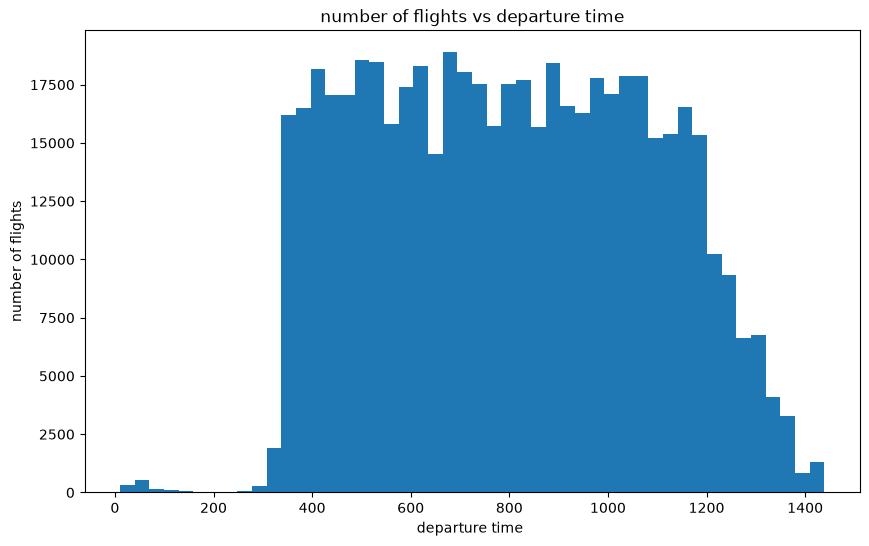

In [11]:
airlines["Time"].describe()
plt.figure(figsize=(10, 6))

plt.hist(airlines["Time"], bins=48)

plt.xlabel("departure time ")
plt.ylabel("number of flights")
plt.title("number of flights vs departure time")

plt.savefig(
    "plots/distribution_of_scheduled_departure_times.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [12]:
airlines["Hour"] = airlines["Time"] // 60

In [13]:
hourly_delay_rate = airlines.groupby("Hour")["Delay"].mean() * 100

hourly_delay_rate

Hour
0     47.132170
1     39.306358
2     44.943820
4     40.404040
5     23.367769
6     25.669729
7     30.205987
8     34.649427
9     40.467551
10    43.663067
11    44.876105
12    46.590000
13    48.324038
14    50.090792
15    51.397961
16    52.136430
17    51.917364
18    53.031255
19    52.142770
20    54.249389
21    48.859913
22    41.679120
23    42.843909
Name: Delay, dtype: float64

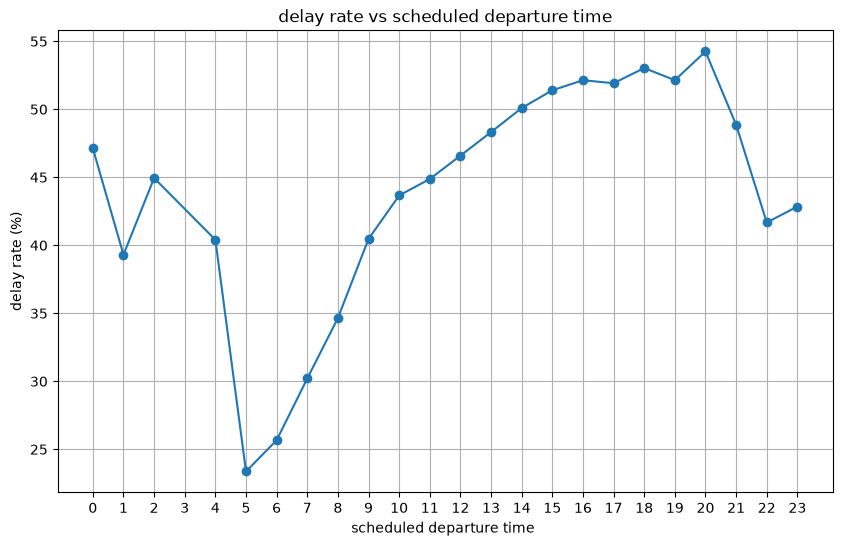

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(hourly_delay_rate.index, hourly_delay_rate.values, marker="o")

plt.xlabel("scheduled departure time ")
plt.ylabel("delay rate (%)")
plt.title("delay rate vs scheduled departure time")
plt.xticks(range(24))
plt.grid(True)

plt.savefig(
    "plots/delay_rate_vs_scheduled_departure_time.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [15]:
airline_delay_rate = (
    airlines.groupby("Airline")["Delay"]
    .mean()
    .sort_values(ascending=False) * 100
)

airline_delay_rate

Airline
WN    69.775870
CO    56.619945
B6    46.703843
OO    45.289927
DL    45.047588
F9    44.903965
EV    40.220848
9E    39.766025
AA    38.847030
XE    37.894365
MQ    34.809452
AS    33.929038
US    33.597101
UA    32.390746
HA    32.018645
FL    30.129159
OH    27.727633
YV    24.291439
Name: Delay, dtype: float64

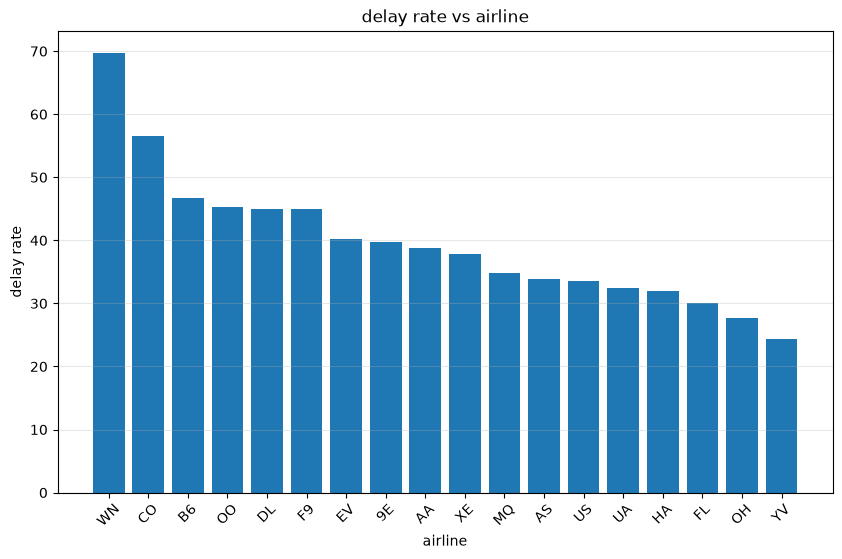

In [16]:
plt.figure(figsize=(10, 6))

plt.bar(
    airline_delay_rate.index,
    airline_delay_rate.values
)

plt.xlabel("airline")
plt.ylabel("delay rate")
plt.title("delay rate vs airline")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "plots/delay_rate_by_airline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
day_delay_rate = (
    airlines.groupby("DayOfWeek")["Delay"]
    .mean()
    * 100
)

day_delay_rate


DayOfWeek
1    46.764419
2    44.733670
3    47.081764
4    45.102521
5    41.660801
6    40.055295
7    45.354112
Name: Delay, dtype: float64

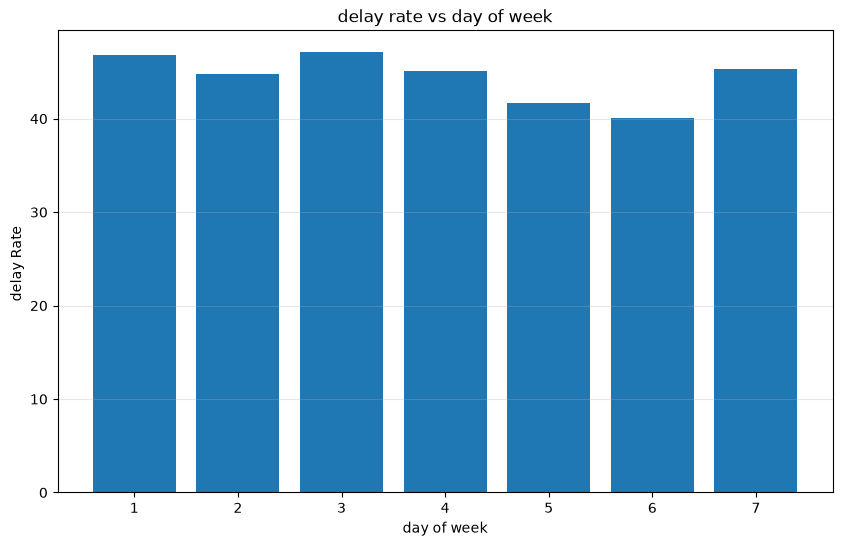

In [18]:
plt.figure(figsize=(10, 6))

plt.bar(
    day_delay_rate.index,
    day_delay_rate.values
)

plt.xlabel("day of week")
plt.ylabel("delay Rate ")
plt.title("delay rate vs day of week")

plt.xticks(range(1, 8))
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "plots/delay_rate_by_day_of_week.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
length_bins = pd.cut(
    airlines["Length"],
    bins=[0, 60, 120, 180, 240, 300, 360, 420, 480, 540, 600, 660],
    right=False
)

length_delay_rate = (
    airlines.groupby(length_bins, observed=True)["Delay"]
    .mean()
    * 100
)

length_delay_rate

Length
[0, 60)       39.147222
[60, 120)     43.706890
[120, 180)    43.823516
[180, 240)    49.451623
[240, 300)    52.935223
[300, 360)    46.489137
[360, 420)    44.912455
[420, 480)    40.776699
[480, 540)    54.826255
[540, 600)    63.043478
[600, 660)    66.176471
Name: Delay, dtype: float64

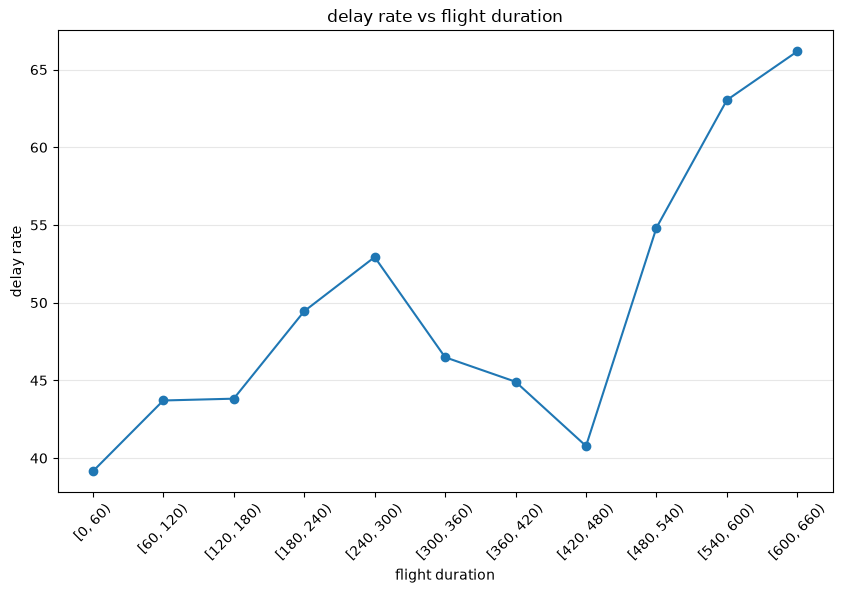

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(
    length_delay_rate.index.astype(str),
    length_delay_rate.values,
    marker="o"
)

plt.xlabel("flight duration")
plt.ylabel("delay rate")
plt.title("delay rate vs flight duration")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "plots/delay_rate_by_flight_duration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
airport_from_counts = airlines["AirportFrom"].value_counts().head(10)

airport_from_counts

AirportFrom
ATL    34449
ORD    24822
DFW    22154
DEN    19843
LAX    16657
IAH    15821
PHX    15557
DTW    13136
LAS    11918
SFO    11786
Name: count, dtype: int64

In [22]:
top_departure_airports = airlines["AirportFrom"].value_counts().head(10).index

airport_delay_rate = (
    airlines[airlines["AirportFrom"].isin(top_departure_airports)]
    .groupby("AirportFrom")["Delay"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

airport_delay_rate

AirportFrom
LAS    55.999329
SFO    53.292041
LAX    49.648796
IAH    48.448265
ORD    47.965514
DTW    47.959805
DEN    47.538175
PHX    43.993058
ATL    42.384394
DFW    39.762571
Name: Delay, dtype: float64

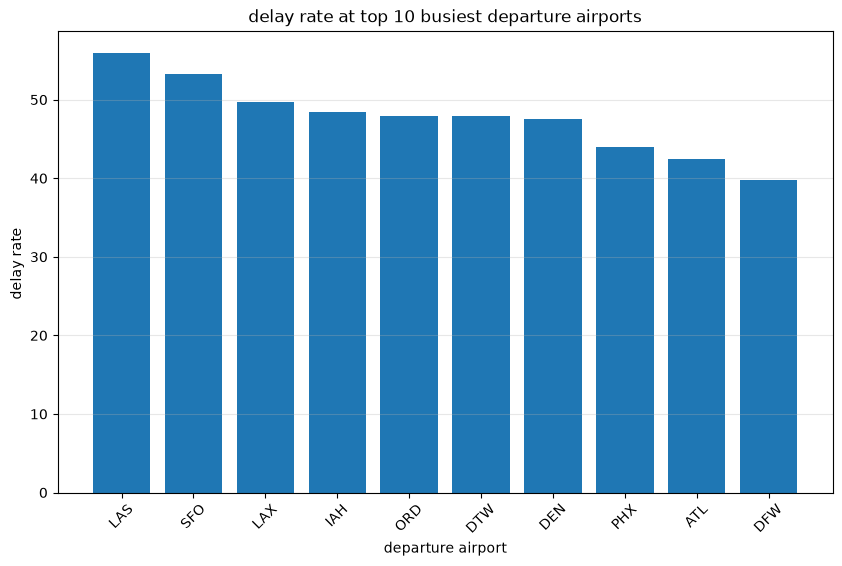

In [23]:
plt.figure(figsize=(10, 6))

plt.bar(
    airport_delay_rate.index,
    airport_delay_rate.values
)

plt.xlabel("departure airport")
plt.ylabel("delay rate ")
plt.title("delay rate at top 10 busiest departure airports")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "plots/delay_rate_by_departure_airport.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
airlines["Time_sin"] = np.sin(2 * np.pi * airlines["Time"] / 1440)
airlines["Time_cos"] = np.cos(2 * np.pi * airlines["Time"] / 1440)

In [25]:
airlines[["Time", "Time_sin", "Time_cos"]].head(10)

,Time,Time_sin,Time_cos
0,15,0.065403,0.997859
1,15,0.065403,0.997859
2,20,0.087156,0.996195
3,20,0.087156,0.996195
4,30,0.130526,0.991445
5,30,0.130526,0.991445
6,30,0.130526,0.991445
7,30,0.130526,0.991445
8,35,0.152123,0.988362
9,40,0.173648,0.984808


In [26]:
airlines["Flight"].nunique()

6585

In [27]:
airlines.head()

,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay,Hour,Time_sin,Time_cos
0,1,CO,269,SFO,IAH,3,15,205,1,0,0.065403,0.997859
1,2,US,1558,PHX,CLT,3,15,222,1,0,0.065403,0.997859
2,3,AA,2400,LAX,DFW,3,20,165,1,0,0.087156,0.996195
3,4,AA,2466,SFO,DFW,3,20,195,1,0,0.087156,0.996195
4,5,AS,108,ANC,SEA,3,30,202,0,0,0.130526,0.991445


In [28]:
airlines.drop(columns=["id", "Flight", "Time", "Hour"], inplace=True)

In [29]:
airlines.head()

,Airline,AirportFrom,AirportTo,DayOfWeek,Length,Delay,Time_sin,Time_cos
0,CO,SFO,IAH,3,205,1,0.065403,0.997859
1,US,PHX,CLT,3,222,1,0.065403,0.997859
2,AA,LAX,DFW,3,165,1,0.087156,0.996195
3,AA,SFO,DFW,3,195,1,0.087156,0.996195
4,AS,ANC,SEA,3,202,0,0.130526,0.991445


In [30]:
airlines.dtypes

Airline            str
AirportFrom        str
AirportTo          str
DayOfWeek        int64
Length           int64
Delay            int64
Time_sin       float64
Time_cos       float64
dtype: object

In [31]:
X = airlines.drop(columns=["Delay"])
y = airlines["Delay"]

In [32]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (539383, 7)
y shape: (539383,)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (431506, 7)
X_test: (107877, 7)
y_train: (431506,)
y_test: (107877,)


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "Airline",
    "AirportFrom",
    "AirportTo",
    "DayOfWeek"
]

numerical_features = [
    "Length",
    "Time_sin",
    "Time_cos"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", StandardScaler(), numerical_features)
    ]
)

In [36]:
X_train_processed = preprocessor.fit_transform(X_train)

In [37]:
X_train_processed.shape

(431506, 614)

In [38]:
airline_encoded.shape


NameError: name 'airline_encoded' is not defined

In [39]:
X_test_processed = preprocessor.transform(X_test)

In [40]:
X_test_processed.shape

(107877, 614)

In [41]:
type(X_train_processed)

scipy.sparse._csr.csr_matrix

In [42]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(X_train_processed, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [43]:
y_pred_logistic = logistic_model.predict(X_test_processed)

In [44]:
y_pred_logistic[:20]

array([0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [45]:
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("logistic regression accuracy:", logistic_accuracy*100)

logistic regression accuracy: 65.0351789538085


In [46]:
from sklearn.metrics import precision_score, recall_score, f1_score

logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)

print("precision:", logistic_precision)
print("recall:", logistic_recall)
print("f1 score:", logistic_f1)

precision: 0.6368089387841559
recall: 0.5005098537032027
f1 score: 0.5604921872269025


In [47]:
from sklearn.metrics import roc_auc_score

y_prob_logistic = logistic_model.predict_proba(X_test_processed)[:, 1]

logistic_roc_auc = roc_auc_score(y_test, y_prob_logistic)

print("logistic regression ROC-AUC:", logistic_roc_auc)

logistic regression ROC-AUC: 0.6969638527274257


In [48]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

In [49]:
y_pred_tree = decision_tree.predict(X_test_processed)

In [50]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("decision tree accuracy:", tree_accuracy*100)

decision tree accuracy: 60.762720505761195


In [51]:
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)

print("precision:", tree_precision)
print("recall:", tree_recall)
print("f1 score:", tree_f1)

precision: 0.5722251658971059
recall: 0.47195804632385074
f1 score: 0.5172775585612298


In [52]:
y_prob_tree = decision_tree.predict_proba(X_test_processed)[:, 1]

tree_roc_auc = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree ROC-AUC:", tree_roc_auc)

Decision Tree ROC-AUC: 0.612958052149804


In [53]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train_processed, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [54]:
y_pred_rf = random_forest.predict(X_test_processed)

y_pred_rf[:20]

array([0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0])

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Accuracy : 0.6152748037116346
Precision: 0.5711029092488059
Recall   : 0.5474163943978524
F1 Score : 0.5590088510620211


In [56]:
from sklearn.metrics import roc_auc_score

y_prob_rf = random_forest.predict_proba(X_test_processed)[:, 1]

rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("ROC-AUC:", rf_roc_auc)

ROC-AUC: 0.6517636820237942


In [57]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)

knn_model.fit(X_train_processed, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",-1
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [58]:
y_pred_knn = knn_model.predict(X_test_processed)

y_pred_knn[:20]

array([0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0])

In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)

Accuracy : 0.6301157800087136
Precision: 0.5909567701475216
Recall   : 0.5510373962083532
F1 Score : 0.5702993754038337


In [60]:
y_prob_knn = knn_model.predict_proba(X_test_processed)[:, 1]

knn_roc_auc = roc_auc_score(y_test, y_prob_knn)

print("ROC-AUC:", knn_roc_auc)

ROC-AUC: 0.6615957803598523


In [61]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42,
    max_iter=1000
)

svm_model.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adj

In [62]:
y_pred_svm = svm_model.predict(X_test_processed)

y_pred_svm[:20]

array([0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

Accuracy : 0.6503054404553333
Precision: 0.638953910727258
Recall   : 0.4942043160676753
F1 Score : 0.5573339591645153


In [64]:
from sklearn.metrics import roc_auc_score

y_score_svm = svm_model.decision_function(X_test_processed)

svm_roc_auc = roc_auc_score(y_test, y_score_svm)

print("ROC-AUC:", svm_roc_auc)

ROC-AUC: 0.6968065791217304


In [65]:
model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": logistic_accuracy,
        "Precision": logistic_precision,
        "Recall": logistic_recall,
        "F1 Score": logistic_f1,
        "ROC-AUC": logistic_roc_auc
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, y_pred_tree),
        "Precision": precision_score(y_test, y_pred_tree),
        "Recall": recall_score(y_test, y_pred_tree),
        "F1 Score": f1_score(y_test, y_pred_tree),
        "ROC-AUC": tree_roc_auc
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1 Score": rf_f1,
        "ROC-AUC": rf_roc_auc
    },
    {
        "Model": "KNN",
        "Accuracy": knn_accuracy,
        "Precision": knn_precision,
        "Recall": knn_recall,
        "F1 Score": knn_f1,
        "ROC-AUC": knn_roc_auc
    },
    {
        "Model": "SVM",
        "Accuracy": svm_accuracy,
        "Precision": svm_precision,
        "Recall": svm_recall,
        "F1 Score": svm_f1,
        "ROC-AUC": svm_roc_auc
    }
])

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.650352,0.636809,0.500510,0.560492,0.696964
1,Decision Tree,0.607627,0.572225,0.471958,0.517278,0.612958
2,Random Forest,0.615275,0.571103,0.547416,0.559009,0.651764
3,KNN,0.630116,0.590957,0.551037,0.570299,0.661596
4,SVM,0.650305,0.638954,0.494204,0.557334,0.696807


In [66]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_model.fit(X_train_processed, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [67]:
y_pred_xgb = xgb_model.predict(X_test_processed)

y_pred_xgb[:20]

array([0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)

Accuracy : 0.660446619761395
Precision: 0.6801678180499038
Recall   : 0.4487128795288536
F1 Score : 0.5407126915264439


In [69]:
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("ROC-AUC:", xgb_roc_auc)

ROC-AUC: 0.7102070599316579


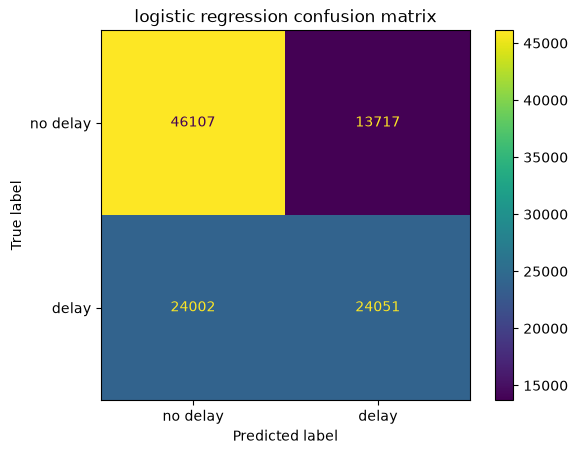

In [70]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["no delay", "delay"]
)

disp.plot()
plt.title("logistic regression confusion matrix")

plt.savefig(
    "plots/logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

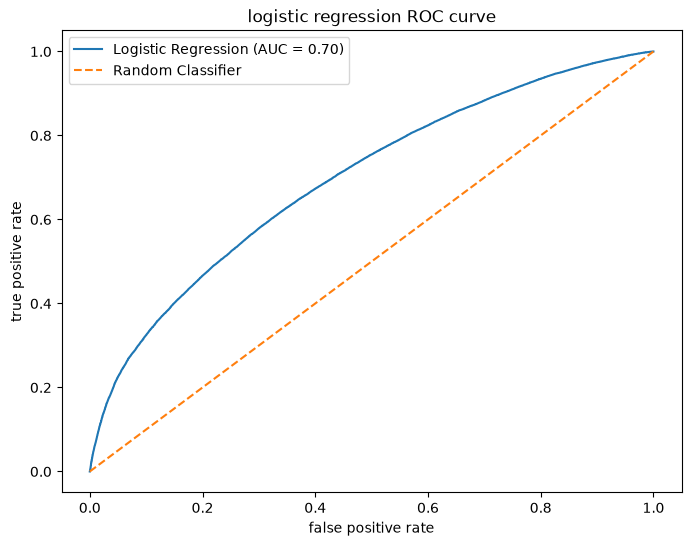

In [72]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob_logistic)
roc_auc = roc_auc_score(y_test, y_prob_logistic)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("logistic regression ROC curve")
plt.legend()

plt.savefig(
    "plots/logistic_regression_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [73]:
model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": logistic_accuracy,
        "Precision": logistic_precision,
        "Recall": logistic_recall,
        "F1 Score": logistic_f1,
        "ROC-AUC": logistic_roc_auc
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, y_pred_tree),
        "Precision": precision_score(y_test, y_pred_tree),
        "Recall": recall_score(y_test, y_pred_tree),
        "F1 Score": f1_score(y_test, y_pred_tree),
        "ROC-AUC": tree_roc_auc
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1 Score": rf_f1,
        "ROC-AUC": rf_roc_auc
    },
    {
        "Model": "KNN",
        "Accuracy": knn_accuracy,
        "Precision": knn_precision,
        "Recall": knn_recall,
        "F1 Score": knn_f1,
        "ROC-AUC": knn_roc_auc
    },
    {
        "Model": "SVM",
        "Accuracy": svm_accuracy,
        "Precision": svm_precision,
        "Recall": svm_recall,
        "F1 Score": svm_f1,
        "ROC-AUC": svm_roc_auc
    }
])

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.650352,0.636809,0.500510,0.560492,0.696964
1,Decision Tree,0.607627,0.572225,0.471958,0.517278,0.612958
2,Random Forest,0.615275,0.571103,0.547416,0.559009,0.651764
3,KNN,0.630116,0.590957,0.551037,0.570299,0.661596
4,SVM,0.650305,0.638954,0.494204,0.557334,0.696807


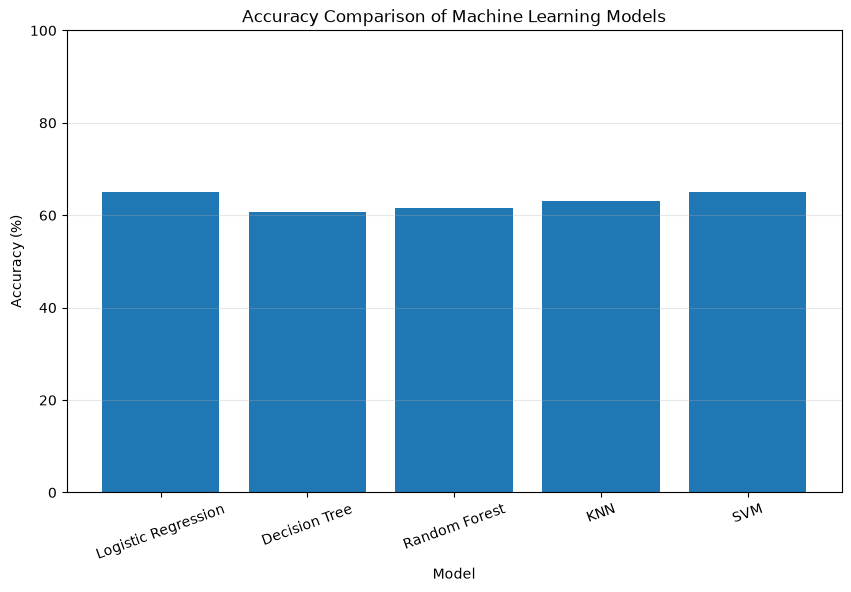

In [74]:
plt.figure(figsize=(10, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy"] * 100
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison of Machine Learning Models")

plt.xticks(rotation=20)
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "plots/model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

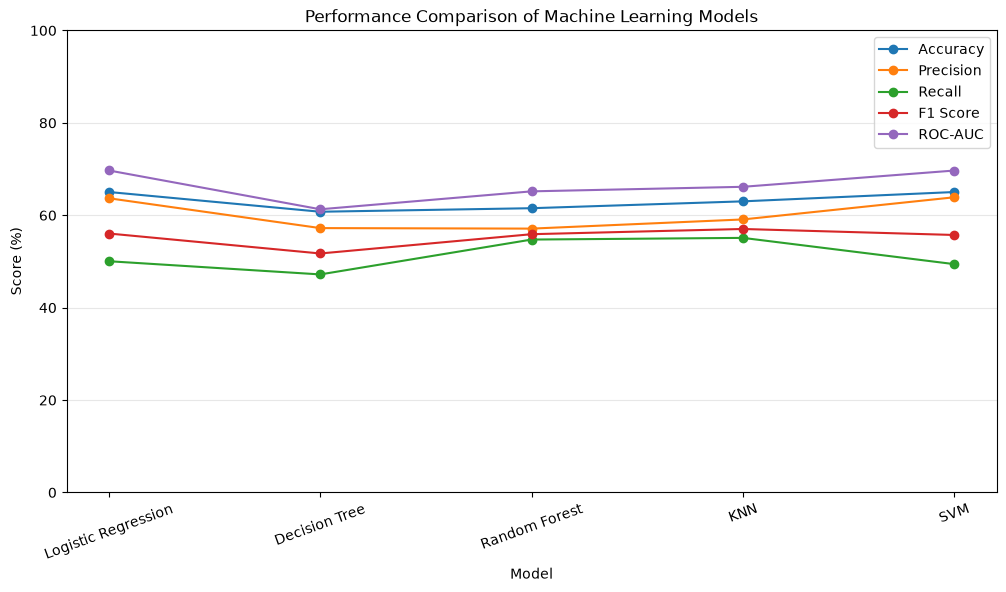

In [75]:
plt.figure(figsize=(12, 6))

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

for metric in metrics:
    plt.plot(
        model_comparison["Model"],
        model_comparison[metric] * 100,
        marker="o",
        label=metric
    )

plt.xlabel("Model")
plt.ylabel("Score (%)")
plt.title("Performance Comparison of Machine Learning Models")

plt.xticks(rotation=20)
plt.ylim(0, 100)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "plots/model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [77]:
import os

os.makedirs("models", exist_ok=True)

print("models folder created.")

models folder created.


In [78]:
import joblib

joblib.dump(preprocessor, "models/preprocessor.pkl")

joblib.dump(logistic_model, "models/logistic_regression.pkl")
joblib.dump(decision_tree, "models/decision_tree.pkl")
joblib.dump(random_forest, "models/random_forest.pkl")
joblib.dump(knn_model, "models/knn.pkl")
joblib.dump(svm_model, "models/svm.pkl")

print("All models and preprocessor saved successfully.")

All models and preprocessor saved successfully.


In [79]:
import os

print(os.listdir("models"))

['svm.pkl', 'decision_tree.pkl', 'knn.pkl', 'logistic_regression.pkl', 'preprocessor.pkl', 'random_forest.pkl']


In [80]:
import joblib

preprocessor_loaded = joblib.load("models/preprocessor.pkl")

logistic_loaded = joblib.load("models/logistic_regression.pkl")
decision_tree_loaded = joblib.load("models/decision_tree.pkl")
random_forest_loaded = joblib.load("models/random_forest.pkl")
knn_loaded = joblib.load("models/knn.pkl")
svm_loaded = joblib.load("models/svm.pkl")

print("All saved models loaded successfully.")

All saved models loaded successfully.


In [81]:
import numpy as np
import pandas as pd


input_data = pd.DataFrame({
    "Airline": ["WN"],
    "AirportFrom": ["ATL"],
    "AirportTo": ["LAX"],
    "DayOfWeek": [1],
    "Length": [240],
    "Time_sin": [np.sin(2 * np.pi * 900 / 1440)],
    "Time_cos": [np.cos(2 * np.pi * 900 / 1440)]
})


input_processed = preprocessor_loaded.transform(input_data)


prediction = logistic_loaded.predict(input_processed)[0]


delay_probability = logistic_loaded.predict_proba(input_processed)[0][1]

print("Prediction:", "Delayed" if prediction == 1 else "Not Delayed")
print(f"Probability of delay: {delay_probability:.2%}") 

Prediction: Delayed
Probability of delay: 87.14%
